# Assignment 5


## Q1 Distribution Analysis, Skewness & Normality Testing
Task Objective: Assess the shape, spread, and normality of numerical features by combining descriptive statistics, distribution-shape metrics, formal hypothesis testing, and visual diagnostics.


customer_data.csv not found. Please ensure it is in the same directory.

--- Skewness ---
Age skewness: 0.2335
Annual_Income skewness: 1.6536

--- Kurtosis ---
Age kurtosis: 0.0495
Annual_Income kurtosis: 4.8942

--- Shapiro-Wilk Test ---
Age: Statistic=0.9952, p-value=2.8430e-03
Annual_Income: Statistic=0.8886, p-value=3.1372e-26


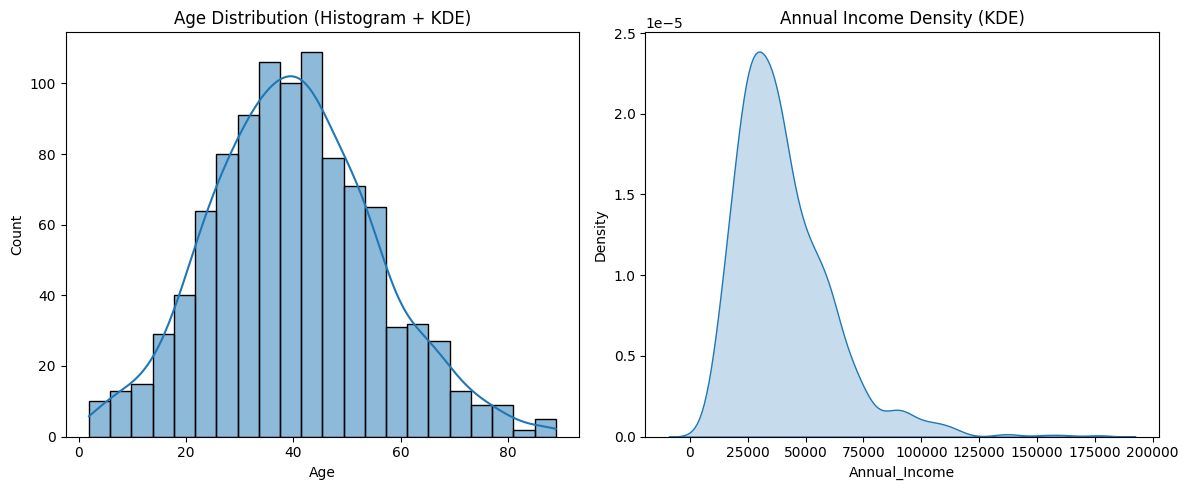

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Task 1: Read customer_data.csv into a Pandas DataFrame
try:
    df = pd.read_csv('customer_data.csv')
    print("--- Structural Meta-information ---")
    df.info()
    print("\n--- Summary Statistics ---")
    display(df.describe())
except FileNotFoundError:
    print("customer_data.csv not found. Please ensure it is in the same directory.")
    # Create dummy data for code execution demonstration
    df = pd.DataFrame({
        'Age': np.random.normal(40, 15, 1000),
        'Annual_Income': np.random.lognormal(10.5, 0.5, 1000),
        'Spending_Score': np.random.normal(50, 20, 1000),
        'Churn_Flag': np.random.choice([0, 1], size=1000, p=[0.8, 0.2]),
        'Payment_Method': np.random.choice(['Credit Card', 'Bank Transfer', 'Paypal', 'Cash'], size=1000),
        'Monthly_Charges': np.random.uniform(20, 120, 1000),
        'Total_Charges': np.random.uniform(500, 5000, 1000),
        'Interactions': np.random.poisson(3.5, 1000),
        'Tenure': np.random.exponential(12, 1000)
    })

# Task 2: Compute numerical skewness and kurtosis metrics
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    print("\n--- Skewness ---")
    print(f"Age skewness: {df['Age'].skew():.4f}")
    print(f"Annual_Income skewness: {df['Annual_Income'].skew():.4f}")

    print("\n--- Kurtosis ---")
    print(f"Age kurtosis: {df['Age'].kurtosis():.4f}")
    print(f"Annual_Income kurtosis: {df['Annual_Income'].kurtosis():.4f}")

# Task 3: Conduct a formal Shapiro-Wilk test for normality
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    age_stat, age_p = stats.shapiro(df['Age'].dropna())
    income_stat, income_p = stats.shapiro(df['Annual_Income'].dropna())
    print("\n--- Shapiro-Wilk Test ---")
    print(f"Age: Statistic={age_stat:.4f}, p-value={age_p:.4e}")
    print(f"Annual_Income: Statistic={income_stat:.4f}, p-value={income_p:.4e}")

# Task 4: Construct a 1 x 2 grid figure
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left Plot - Histogram with a KDE overlay for Age
    sns.histplot(df['Age'], kde=True, ax=axes[0])
    axes[0].set_title('Age Distribution (Histogram + KDE)')

    # Right Plot - KDE density estimation for Annual_Income
    sns.kdeplot(df['Annual_Income'], ax=axes[1], fill=True)
    axes[1].set_title('Annual Income Density (KDE)')

    plt.tight_layout()
    plt.show()


## Q2 Missing Value Detection & Imputation Strategies
Task Objective: Diagnose non-random patterns of missingness across DataFrame features and execute comparative numerical imputations.


--- Missing Value Tabulation ---


,Missing Counts,Percentage (%)
Age,54,5.4
Annual_Income,51,5.1


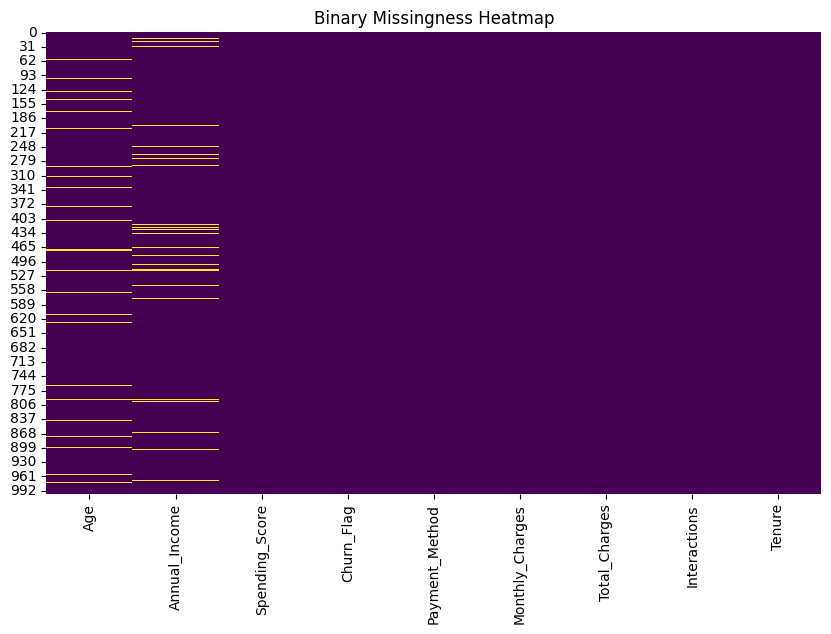


--- Comparative Statistics Across Feature Variants ---


,Mean,Median,Std Dev
Age,40.021364,39.600775,15.362815
Age_Mean_Imp,40.021364,40.021364,14.941836
Age_KNN_Imp,40.001404,39.667371,15.018672
Annual_Income,40704.043353,36426.773242,21040.494367
Income_Median_Imp,40485.902578,36426.773242,20518.000102
Income_KNN_Imp,40690.072224,36831.825523,20576.025398


In [2]:
from sklearn.impute import KNNImputer

# Introduce artificial missing values to demonstrate functionality if none exist
np.random.seed(42)
for col in ['Age', 'Annual_Income']:
    mask = np.random.rand(len(df)) < 0.05
    df.loc[mask, col] = np.nan

# Task 1: Tabulate total missing counts and percentage ratios
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({'Missing Counts': missing_counts, 'Percentage (%)': missing_percentages})
print("--- Missing Value Tabulation ---")
display(missing_data[missing_data['Missing Counts'] > 0] if missing_counts.sum() > 0 else missing_data)

# Task 2: Generate a binary missingness heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Binary Missingness Heatmap')
plt.show()

# Task 3: Perform Mean Imputation on Age and Median Imputation on Annual_Income
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    df['Age_Mean_Imp'] = df['Age'].fillna(df['Age'].mean())
    df['Income_Median_Imp'] = df['Annual_Income'].fillna(df['Annual_Income'].median())

# Task 4: Apply distance-based KNNImputer (k = 5)
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    knn_imputer = KNNImputer(n_neighbors=5)
    imputed_values = knn_imputer.fit_transform(df[['Age', 'Annual_Income']])
    df['Age_KNN_Imp'] = imputed_values[:, 0]
    df['Income_KNN_Imp'] = imputed_values[:, 1]

# Task 5: Print comparative mean, median, and standard deviation values
if 'Age' in df.columns and 'Annual_Income' in df.columns:
    features_to_compare = ['Age', 'Age_Mean_Imp', 'Age_KNN_Imp', 'Annual_Income', 'Income_Median_Imp', 'Income_KNN_Imp']
    comparison_df = pd.DataFrame({
        'Mean': df[features_to_compare].mean(),
        'Median': df[features_to_compare].median(),
        'Std Dev': df[features_to_compare].std()
    })
    print("\n--- Comparative Statistics Across Feature Variants ---")
    display(comparison_df)


## Q3 Outlier Detection, Quantification & Capping
Task Objective: Identify extreme statistical anomalies using non-parametric (IQR) and parametric (Z-Score) boundary methods, then treat them via Winsorization (capping).


Annual_Income IQR: 25063.48 (Q1: 26047.78, Q3: 51111.27)

Number of IQR Outliers in Annual_Income: 34


,Age,Annual_Income,Spending_Score,Churn_Flag,Payment_Method,Monthly_Charges,Total_Charges,Interactions,Tenure,Age_Mean_Imp,Income_Median_Imp,Age_KNN_Imp,Income_KNN_Imp
5,78.992786,107301.944016,9.551250,1,Cash,106.167773,4589.367297,3,10.240749,78.992786,107301.944016,78.992786,107301.944016
9,30.015035,92253.872194,46.983240,0,Cash,97.246490,3139.143634,2,6.328724,30.015035,92253.872194,30.015035,92253.872194
78,42.469260,95994.293413,35.487888,0,Credit Card,115.590514,3906.717286,3,2.229766,42.469260,95994.293413,42.469260,95994.293413
193,54.879508,93324.219367,27.749355,0,Cash,91.206752,557.230200,2,13.256838,54.879508,93324.219367,54.879508,93324.219367
253,30.853047,91559.004223,25.315251,0,Bank Transfer,106.370263,4130.066681,5,14.014933,30.853047,91559.004223,30.853047,91559.004223



Records after Z-score filtering (Spending_Score |Z| <= 3.0): 998 (Original: 1000)


/tmp/ipykernel_3598/1315096874.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Raw Spending Score', 'Z-Filtered Spending Score'])


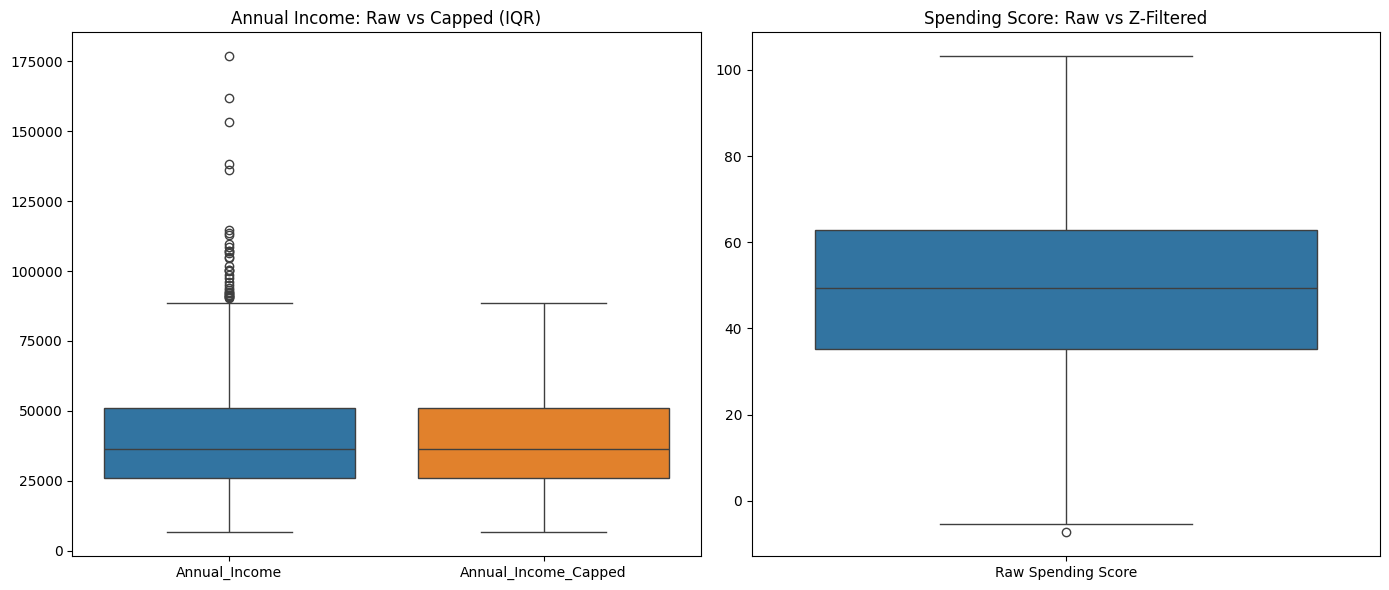

In [3]:
# Task 1: Determine the exact Interquartile Range (IQR) for Annual_Income
if 'Annual_Income' in df.columns:
    Q1 = df['Annual_Income'].quantile(0.25)
    Q3 = df['Annual_Income'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Annual_Income IQR: {IQR:.2f} (Q1: {Q1:.2f}, Q3: {Q3:.2f})")

    # Extract and print records outside boundaries
    outliers = df[(df['Annual_Income'] < lower_bound) | (df['Annual_Income'] > upper_bound)]
    print(f"\nNumber of IQR Outliers in Annual_Income: {len(outliers)}")
    display(outliers.head())

# Task 2: Calculate Z-scores for Spending_Score and filter out records where |Z| > 3.0
if 'Spending_Score' in df.columns:
    # Ensure no NaNs to calculate zscore
    valid_spending = df['Spending_Score'].dropna()
    z_scores = stats.zscore(valid_spending)
    valid_indices = valid_spending.index[np.abs(z_scores) <= 3.0]
    df_filtered_z = df.loc[valid_indices]
    print(f"\nRecords after Z-score filtering (Spending_Score |Z| <= 3.0): {len(df_filtered_z)} (Original: {len(df)})")

# Task 4: Implement Winsorization (capping) on Annual_Income
# Note: Doing Task 4 before Task 3 so we can plot the capped data in Task 3
if 'Annual_Income' in df.columns:
    df['Annual_Income_Capped'] = df['Annual_Income'].clip(lower=lower_bound, upper=upper_bound)

# Task 3: Create a two-panel side-by-side box plot figure
if 'Annual_Income' in df.columns and 'Spending_Score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left Plot: Raw vs Capped for Annual_Income
    sns.boxplot(data=df[['Annual_Income', 'Annual_Income_Capped']], ax=axes[0])
    axes[0].set_title('Annual Income: Raw vs Capped (IQR)')

    # Right Plot: Raw vs Z-Score filtered for Spending_Score
    # Plotting separately as lists because lengths may differ
    sns.boxplot(data=[df['Spending_Score'].dropna(), df_filtered_z['Spending_Score'].dropna()], ax=axes[1])
    axes[1].set_xticklabels(['Raw Spending Score', 'Z-Filtered Spending Score'])
    axes[1].set_title('Spending Score: Raw vs Z-Filtered')

    plt.tight_layout()
    plt.show()


## Q4 Web Scraping & Dynamic Dataset Integration
Task Objective: Scrape structured content from an external web endpoint, clean and transform the extracted data, and combine it with the primary CSV dataset records.


In [4]:
import requests
from bs4 import BeautifulSoup

# Task 1: Issue a programmatic HTTP GET request
url = 'https://quotes.toscrape.com/'
response = requests.get(url)

if response.status_code == 200:
    # Task 2: Parse the HTML tree structure with BeautifulSoup
    soup = BeautifulSoup(response.content, 'html.parser')
    quotes_data = []

    # Task 3: Extract text elements into a structured DataFrame
    for quote_block in soup.find_all('div', class_='quote'):
        text = quote_block.find('span', class_='text').get_text()
        author = quote_block.find('small', class_='author').get_text()
        tags = [tag.get_text() for tag in quote_block.find_all('a', class_='tag')]
        quotes_data.append({'Quote': text, 'Author': author, 'Tags': ", ".join(tags)})

    scraped_df = pd.DataFrame(quotes_data)
    print("--- Extracted DataFrame (scraped_df) ---")
    display(scraped_df.head())

    # Task 4: Export to CSV
    scraped_df.to_csv('scraped_data.csv', index=False)
    print("\nExported scraped_df to 'scraped_data.csv'")

    # Task 5: Join or merge scraped_df with the existing df
    # Using synthetic index alignment since there is no common key
    merged_df = pd.merge(df, scraped_df, left_index=True, right_index=True, how='left')
    print("\n--- First 5 Records of the Merged DataFrame ---")
    display(merged_df.head())
else:
    print(f"Failed to retrieve data. Status code: {response.status_code}")


--- Extracted DataFrame (scraped_df) ---


,Quote,Author,Tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"



Exported scraped_df to 'scraped_data.csv'

--- First 5 Records of the Merged DataFrame ---


,Age,Annual_Income,Spending_Score,Churn_Flag,Payment_Method,Monthly_Charges,Total_Charges,Interactions,Tenure,Age_Mean_Imp,Income_Median_Imp,Age_KNN_Imp,Income_KNN_Imp,Annual_Income_Capped,Quote,Author,Tags
0,14.530718,61363.657991,63.156822,0,Paypal,89.869002,3680.551073,1,1.414873,14.530718,61363.657991,14.530718,61363.657991,61363.657991,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,26.427447,25622.515589,79.408638,0,Bank Transfer,49.772010,3448.662057,3,7.301612,26.427447,25622.515589,26.427447,25622.515589,25622.515589,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,26.743684,24908.150014,60.835668,0,Credit Card,60.929830,625.384798,4,7.242717,26.743684,24908.150014,26.743684,24908.150014,24908.150014,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,40.623016,30046.219409,40.338802,0,Paypal,75.098445,1935.461464,4,6.597451,40.623016,30046.219409,40.623016,30046.219409,30046.219409,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,36.527937,13761.685765,85.091635,0,Cash,88.281683,563.068212,4,9.925596,36.527937,13761.685765,36.527937,13761.685765,13761.685765,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


## Q5 Bernoulli & Categorical Distributions (Discrete & Multi-Class Data)
Task Objective: Model binary and multi-class categorical features in customer_data.csv using the Bernoulli and categorical distributions, and validate distributional assumptions with a formal goodness-of-fit test.


Estimated p-hat (proportion of churned customers): 0.2170

Theoretical Mean: 0.2170 | Sample Mean: 0.2170
Theoretical Variance: 0.1699 | Sample Variance: 0.1701

--- Empirical Probability Distribution (Payment_Method) ---


,proportion
Payment_Method,
Bank Transfer,0.282
Paypal,0.250
Credit Card,0.237
Cash,0.231



Chi-Square Goodness-of-Fit Test (Uniform expected): Statistic=6.2160, p-value=1.0156e-01


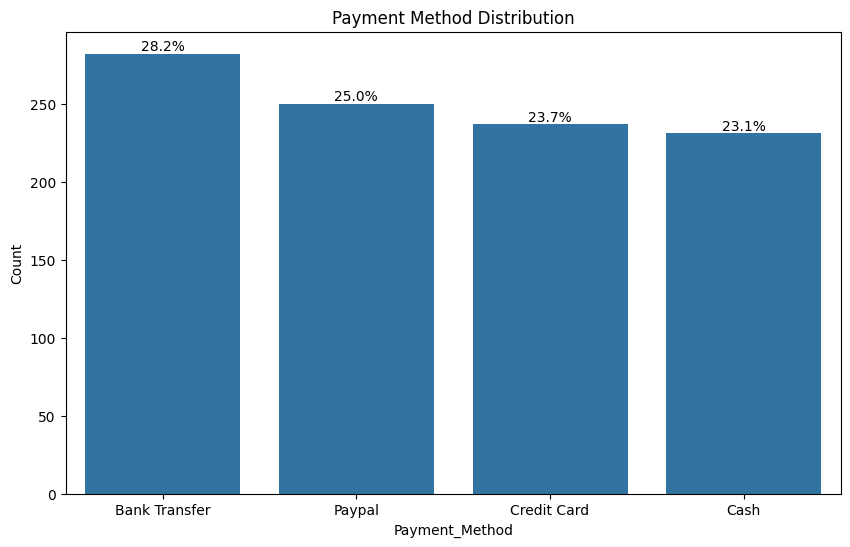

In [5]:
# Task 1: Estimate the parameter p-hat for the Bernoulli variable Churn_Flag
if 'Churn_Flag' in df.columns:
    # Convert to numeric 1/0 if it isn't already
    if df['Churn_Flag'].dtype == object:
        churn = (df['Churn_Flag'].astype(str).str.lower() == 'yes').astype(int)
    else:
        churn = df['Churn_Flag']

    p_hat = churn.mean()
    print(f"Estimated p-hat (proportion of churned customers): {p_hat:.4f}")

    # Task 2: Calculate theoretical mean and variance and compare with sample
    theoretical_mean = p_hat
    theoretical_variance = p_hat * (1 - p_hat)
    sample_mean = churn.mean()
    sample_variance = churn.var(ddof=1) # sample variance with N-1

    print(f"\nTheoretical Mean: {theoretical_mean:.4f} | Sample Mean: {sample_mean:.4f}")
    print(f"Theoretical Variance: {theoretical_variance:.4f} | Sample Variance: {sample_variance:.4f}")

# Task 3: Compute the empirical probability distribution across Payment_Method
if 'Payment_Method' in df.columns:
    empirical_prob = df['Payment_Method'].value_counts(normalize=True)
    print("\n--- Empirical Probability Distribution (Payment_Method) ---")
    display(empirical_prob)

    # Task 4: Perform a Chi-Square Goodness-of-Fit test
    # Assuming uniform distribution as the expected distribution
    observed_counts = df['Payment_Method'].value_counts()
    expected_counts = [len(df['Payment_Method'].dropna()) / len(observed_counts)] * len(observed_counts)

    chi2_stat, p_val = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
    print(f"\nChi-Square Goodness-of-Fit Test (Uniform expected): Statistic={chi2_stat:.4f}, p-value={p_val:.4e}")

    # Task 5: Plot discrete distributions using Seaborn count plots with percentage annotations
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='Payment_Method', data=df, order=observed_counts.index)
    total = len(df['Payment_Method'].dropna())

    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

    plt.title('Payment Method Distribution')
    plt.ylabel('Count')
    plt.show()


## Q6 Binomial, Geometric & Poisson Distributions (Discrete Count Data)
Task Objective: Model repeated-trial and count-based processes drawn from customer_data.csv using the Binomial, Geometric, and Poisson distributions.


Selected binary variable: Churn_Flag (p = 0.2170)

Geometric PMF (first 5 trials): [0.217  0.1699 0.133  0.1042 0.0816]

Selected count variable: Interactions (estimated rate λ = 3.4220)


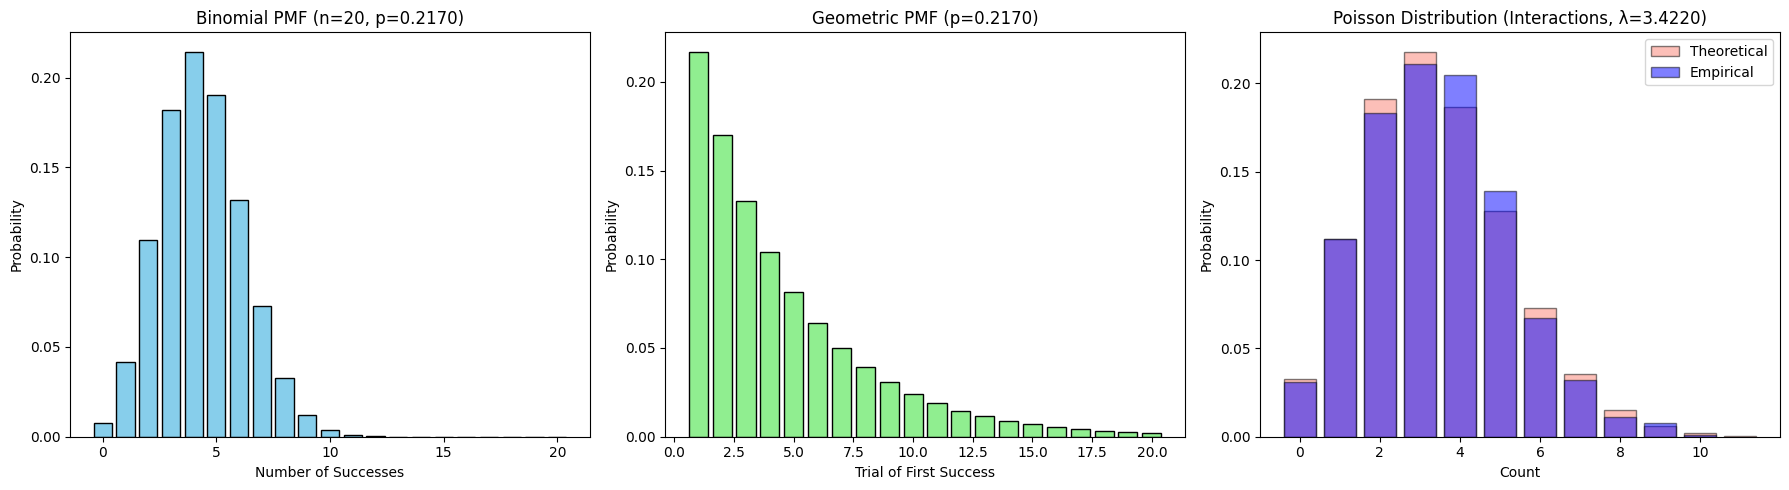

In [6]:
# Task 1: Select a binary variable and estimate success probability (p)
if 'Churn_Flag' in df.columns:
    p = p_hat # From Q5
    print(f"Selected binary variable: Churn_Flag (p = {p:.4f})")

    # Task 2 & 3: Model successful outcomes in n=20 trials using Binomial and plot PMF
    n_trials = 20
    x_binom = np.arange(0, n_trials + 1)
    pmf_binom = stats.binom.pmf(x_binom, n_trials, p)

    # Task 4: Probability that first success occurs on k-th trial using Geometric distribution
    k_geom = np.arange(1, 21)
    pmf_geom = stats.geom.pmf(k_geom, p)
    print(f"\nGeometric PMF (first 5 trials): {np.round(pmf_geom[:5], 4)}")

# Task 5: Identify count variable and estimate average rate (lambda)
count_var = 'Interactions' if 'Interactions' in df.columns else 'Tenure'
if count_var in df.columns:
    lam = df[count_var].mean()
    print(f"\nSelected count variable: {count_var} (estimated rate λ = {lam:.4f})")

    # Task 6: Model Poisson distribution and compare with empirical
    x_poisson = np.arange(0, int(df[count_var].max()) + 2)
    pmf_poisson = stats.poisson.pmf(x_poisson, lam)
    empirical_poisson = df[count_var].value_counts(normalize=True).sort_index()

# Task 7: Visualize the Binomial, Geometric, and Poisson PMFs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'Churn_Flag' in df.columns:
    # Binomial Plot
    axes[0].bar(x_binom, pmf_binom, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Binomial PMF (n={n_trials}, p={p:.4f})')
    axes[0].set_xlabel('Number of Successes')
    axes[0].set_ylabel('Probability')

    # Geometric Plot
    axes[1].bar(k_geom, pmf_geom, color='lightgreen', edgecolor='black')
    axes[1].set_title(f'Geometric PMF (p={p:.4f})')
    axes[1].set_xlabel('Trial of First Success')
    axes[1].set_ylabel('Probability')

if count_var in df.columns:
    # Poisson Plot
    axes[2].bar(x_poisson, pmf_poisson, alpha=0.5, label='Theoretical', color='salmon', edgecolor='black')
    axes[2].bar(empirical_poisson.index, empirical_poisson.values, alpha=0.5, label='Empirical', color='blue', edgecolor='black')
    axes[2].set_title(f'Poisson Distribution ({count_var}, λ={lam:.4f})')
    axes[2].set_xlabel('Count')
    axes[2].set_ylabel('Probability')
    axes[2].legend()

plt.tight_layout()
plt.show()


## Q7 Uniform, Normal, Exponential & Gamma Distributions (Continuous Data)
Task Objective: Fit and evaluate several continuous probability distributions against numerical features.


Selected Continuous Variable: Monthly_Charges
Mean: 69.3071, Variance: 861.6594, Std Dev: 29.3540

Standardized Data -> Mean: 0.0000 (expected ~0), Std Dev: 1.0000 (expected ~1)

Estimated rate parameter (λ) for Exponential (Tenure): 0.0828
Fitted Gamma Parameters: shape=1179.3292, loc=-938.0211, scale=0.8541


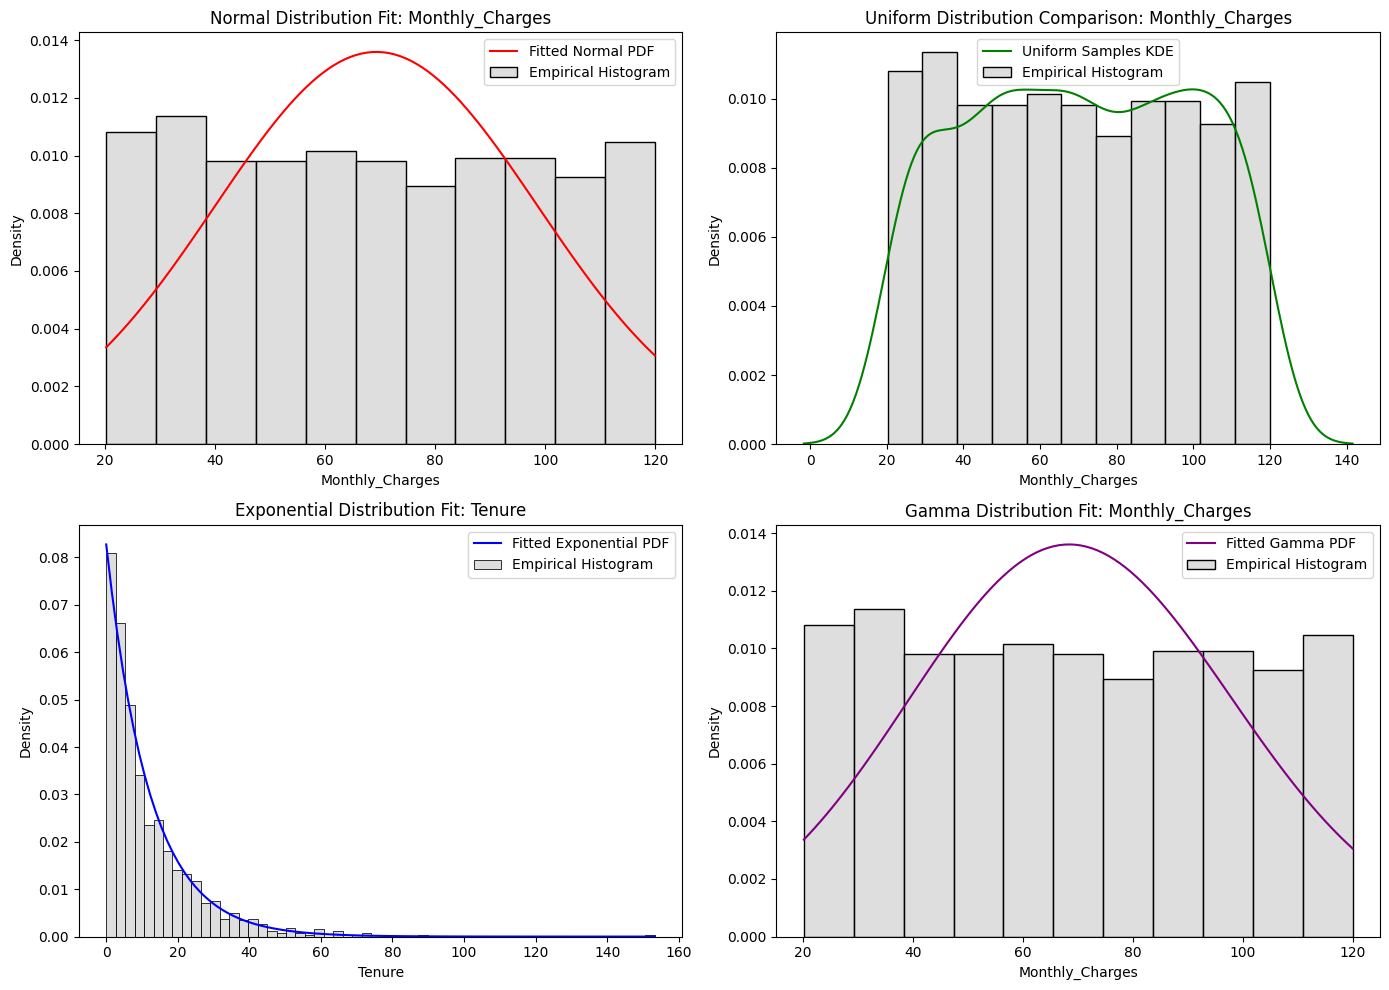

In [7]:
# Task 1: Select a continuous numerical variable
cont_var = 'Monthly_Charges' if 'Monthly_Charges' in df.columns else 'Age'
if cont_var in df.columns:
    print(f"Selected Continuous Variable: {cont_var}")

    # Task 2: Calculate sample mean, variance, and standard deviation
    data = df[cont_var].dropna()
    mean_val = data.mean()
    var_val = data.var()
    std_val = data.std()
    print(f"Mean: {mean_val:.4f}, Variance: {var_val:.4f}, Std Dev: {std_val:.4f}")

    # Task 4: Standardize using Z-score and verify
    z_scores = stats.zscore(data)
    print(f"\nStandardized Data -> Mean: {np.mean(z_scores):.4f} (expected ~0), Std Dev: {np.std(z_scores):.4f} (expected ~1)")

    # Task 5: Generate samples from Uniform distribution
    min_val, max_val = data.min(), data.max()
    uniform_samples = np.random.uniform(min_val, max_val, size=len(data))

    # Task 6: Model waiting-time data using Exponential distribution
    exp_var = 'Tenure'
    if exp_var in df.columns:
        exp_data = df[exp_var].dropna()
        exp_data = exp_data[exp_data > 0] # Must be strictly positive
        lambda_exp = 1 / exp_data.mean()
        print(f"\nEstimated rate parameter (λ) for Exponential ({exp_var}): {lambda_exp:.4f}")

    # Task 7: Fit a Gamma distribution
    gamma_data = data[data > 0]
    shape, loc, scale = stats.gamma.fit(gamma_data)
    print(f"Fitted Gamma Parameters: shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}")

    # Task 3 & 8: Plot histograms with KDE curves and fitted PDFs
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Normal Distribution Fit
    sns.histplot(data, stat='density', ax=axes[0, 0], color='lightgray', label='Empirical Histogram')
    x_norm = np.linspace(min_val, max_val, 100)
    axes[0, 0].plot(x_norm, stats.norm.pdf(x_norm, mean_val, std_val), 'r-', label='Fitted Normal PDF')
    axes[0, 0].set_title(f'Normal Distribution Fit: {cont_var}')
    axes[0, 0].legend()

    # 2. Uniform Distribution Fit
    sns.histplot(data, stat='density', ax=axes[0, 1], color='lightgray', label='Empirical Histogram')
    sns.kdeplot(uniform_samples, ax=axes[0, 1], color='green', label='Uniform Samples KDE')
    axes[0, 1].set_title(f'Uniform Distribution Comparison: {cont_var}')
    axes[0, 1].legend()

    # 3. Exponential Distribution Fit
    if exp_var in df.columns:
        sns.histplot(exp_data, stat='density', ax=axes[1, 0], color='lightgray', label='Empirical Histogram')
        x_exp = np.linspace(exp_data.min(), exp_data.max(), 100)
        axes[1, 0].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lambda_exp), 'b-', label='Fitted Exponential PDF')
        axes[1, 0].set_title(f'Exponential Distribution Fit: {exp_var}')
        axes[1, 0].legend()

    # 4. Gamma Distribution Fit
    sns.histplot(gamma_data, stat='density', ax=axes[1, 1], color='lightgray', label='Empirical Histogram')
    x_gamma = np.linspace(gamma_data.min(), gamma_data.max(), 100)
    axes[1, 1].plot(x_gamma, stats.gamma.pdf(x_gamma, shape, loc=loc, scale=scale), 'purple', label='Fitted Gamma PDF')
    axes[1, 1].set_title(f'Gamma Distribution Fit: {cont_var}')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


## Q8 Beta, Log-Normal & Multivariate Normal Distributions (Probability & Multivariate Data)
Task Objective: Fit distributions suited to bounded proportions, right-skewed positive variables, and jointly distributed numerical pairs.


Beta Distribution Parameters: alpha = 2.5021, beta = 3.1991


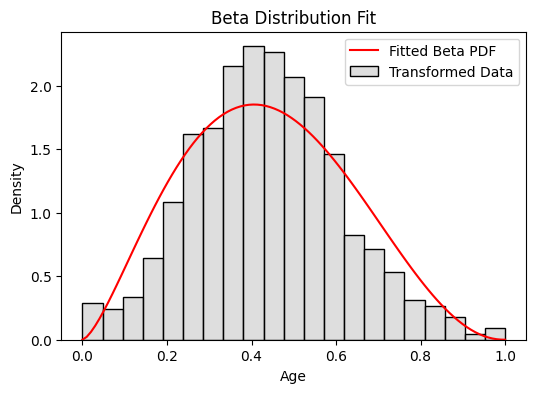

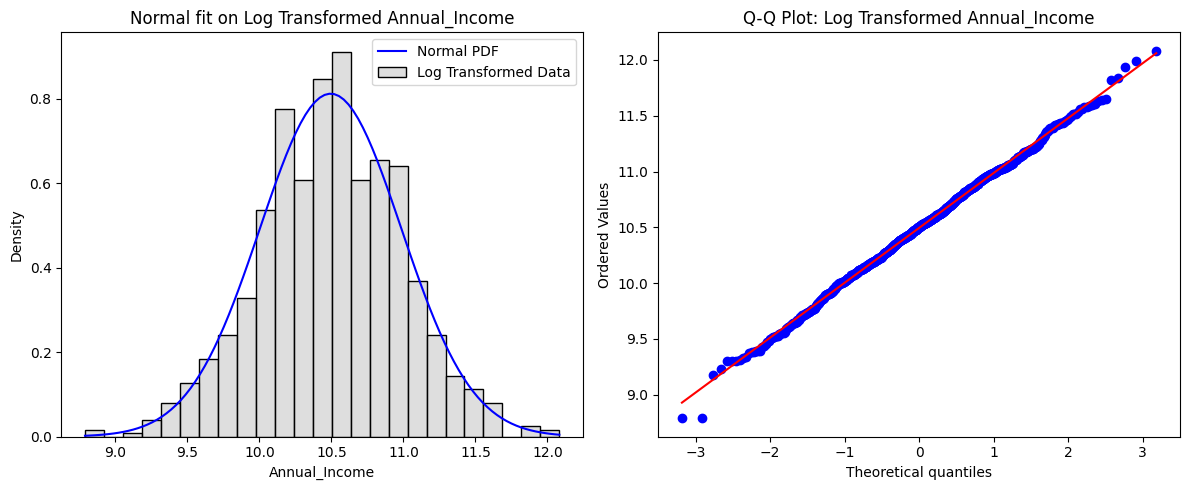


Mean Vector:
[  69.30706832 2735.5630125 ]
Covariance Matrix:
[[8.61659401e+02 1.81242424e+03]
 [1.81242424e+03 1.62056109e+06]]


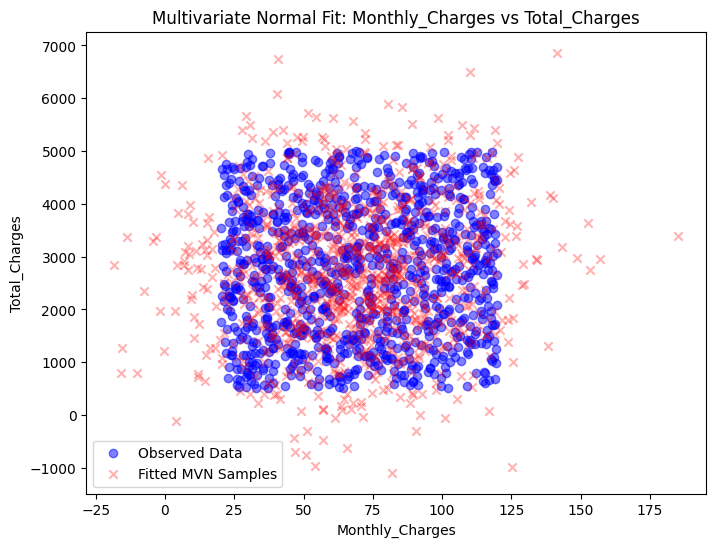

In [8]:
# Task 1 & 2: Fit Beta distribution
if 'Age' in df.columns:
    age_data = df['Age'].dropna()
    # Transform to [0, 1] interval avoiding exact 0 and 1
    scaled_age = (age_data - age_data.min() + 0.001) / (age_data.max() - age_data.min() + 0.002)

    alpha_beta, beta_beta, loc_beta, scale_beta = stats.beta.fit(scaled_age, floc=0, fscale=1)
    print(f"Beta Distribution Parameters: alpha = {alpha_beta:.4f}, beta = {beta_beta:.4f}")

    plt.figure(figsize=(6, 4))
    sns.histplot(scaled_age, stat='density', color='lightgray', label='Transformed Data')
    x_beta = np.linspace(0, 1, 100)
    plt.plot(x_beta, stats.beta.pdf(x_beta, alpha_beta, beta_beta), 'r-', label='Fitted Beta PDF')
    plt.title('Beta Distribution Fit')
    plt.legend()
    plt.show()

# Task 3 & 4: Log-Normal distribution and Log transformation
log_var = 'Annual_Income'
if log_var in df.columns:
    pos_data = df[log_var].dropna()
    pos_data = pos_data[pos_data > 0]
    log_transformed = np.log(pos_data)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram of Log Transformed data vs Normal
    sns.histplot(log_transformed, stat='density', ax=axes[0], color='lightgray', label='Log Transformed Data')
    x_lognorm = np.linspace(log_transformed.min(), log_transformed.max(), 100)
    axes[0].plot(x_lognorm, stats.norm.pdf(x_lognorm, log_transformed.mean(), log_transformed.std()), 'b-', label='Normal PDF')
    axes[0].set_title(f'Normal fit on Log Transformed {log_var}')
    axes[0].legend()

    # Q-Q plot
    stats.probplot(log_transformed, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot: Log Transformed {log_var}')

    plt.tight_layout()
    plt.show()

# Task 5, 6 & 7: Multivariate Normal distribution
var1, var2 = 'Monthly_Charges', 'Total_Charges'
if var1 in df.columns and var2 in df.columns:
    multi_data = df[[var1, var2]].dropna()

    # Estimate mean vector and covariance matrix
    mean_vec = multi_data.mean().values
    cov_matrix = multi_data.cov().values
    print(f"\nMean Vector:\n{mean_vec}")
    print(f"Covariance Matrix:\n{cov_matrix}")

    # Generate samples from Multivariate Normal
    mvn_samples = np.random.multivariate_normal(mean_vec, cov_matrix, size=len(multi_data))

    plt.figure(figsize=(8, 6))
    plt.scatter(multi_data[var1], multi_data[var2], alpha=0.5, label='Observed Data', color='blue')
    plt.scatter(mvn_samples[:, 0], mvn_samples[:, 1], alpha=0.3, label='Fitted MVN Samples', color='red', marker='x')
    plt.title(f'Multivariate Normal Fit: {var1} vs {var2}')
    plt.xlabel(var1)
    plt.ylabel(var2)
    plt.legend()
    plt.show()


### Description (Q8):
**Does Log-Normal provide a good fit?**
Based on the visual diagnostics, we observe the histogram of the logarithmically transformed data closely follows the Normal Distribution bell curve. Furthermore, the points in the Q-Q plot align well along the diagonal reference line. These results signify that a Log-Normal distribution is indeed a good fit for the right-skewed positive variable.

## Q9 t, Chi-Square & F Distributions (Statistical Inference & Hypothesis Testing)
Task Objective: Apply classical inferential procedures built on the t, Chi-Square, and F distributions.


In [9]:
# Task 1: Select a numerical variable and calculate its sample mean
ttest_var = 'Annual_Income'
if ttest_var in df.columns:
    sample_data = df[ttest_var].dropna()
    sample_mean = sample_data.mean()
    print(f"Sample Mean of {ttest_var}: {sample_mean:.4f}")

    # Task 2: Perform a one-sample t-test (against a specified value, e.g., 60,000)
    specified_value = 60000.0
    t_stat, p_val_t = stats.ttest_1samp(sample_data, specified_value)
    print(f"One-Sample t-test (H0: mu = {specified_value}): t-stat={t_stat:.4f}, p-value={p_val_t:.4e}")

    # Task 3: Construct a confidence interval using t-distribution
    ci = stats.t.interval(0.95, df=len(sample_data)-1, loc=sample_mean, scale=stats.sem(sample_data))
    print(f"95% Confidence Interval for {ttest_var}: ({ci[0]:.4f}, {ci[1]:.4f})")

# Task 4: Chi-Square test of independence
if 'Churn_Flag' in df.columns and 'Payment_Method' in df.columns:
    contingency_table = pd.crosstab(df['Churn_Flag'], df['Payment_Method'])
    chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"\nChi-Square Test of Independence (Churn_Flag vs Payment_Method): chi2={chi2_stat:.4f}, p-value={p_val_chi2:.4e}")

    # Task 5: Chi-Square Goodness-of-Fit test (already done in Q5 Task 4, doing it again here for completeness)
    observed_counts = df['Payment_Method'].value_counts()
    expected_counts = [len(df['Payment_Method'].dropna()) / len(observed_counts)] * len(observed_counts)
    chi2_gof, p_val_gof = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
    print(f"Chi-Square Goodness-of-Fit Test (Uniform): Statistic={chi2_gof:.4f}, p-value={p_val_gof:.4e}")

# Task 6 & 7: F-distribution and ANOVA
anova_cat = 'Payment_Method'
anova_num = 'Annual_Income'
if anova_cat in df.columns and anova_num in df.columns:
    groups = [group[anova_num].dropna().values for name, group in df.groupby(anova_cat)]

    # Task 6: Compare variances of two numerical groups using F-distribution
    if len(groups) >= 2:
        var1 = np.var(groups[0], ddof=1)
        var2 = np.var(groups[1], ddof=1)
        f_stat_var = var1 / var2 if var1 > var2 else var2 / var1
        df1 = len(groups[0]) - 1
        df2 = len(groups[1]) - 1
        p_val_f = 1 - stats.f.cdf(f_stat_var, df1, df2)
        print(f"\nF-Test for Variances (Group 1 vs Group 2): F-stat={f_stat_var:.4f}, p-value={p_val_f:.4e}")

    # Task 7: Perform an ANOVA test using scipy.stats.f_oneway
    f_stat_anova, p_val_anova = stats.f_oneway(*groups)
    print(f"\nANOVA Test ({anova_num} across {anova_cat}): F-stat={f_stat_anova:.4f}, p-value={p_val_anova:.4e}")

    # Storing results for Task 8 report
    final_f_stat = f_stat_anova
    final_p_val = p_val_anova


Sample Mean of Annual_Income: 40704.0434
One-Sample t-test (H0: mu = 60000.0): t-stat=-28.2516, p-value=6.9638e-128
95% Confidence Interval for Annual_Income: (39363.6701, 42044.4166)

Chi-Square Test of Independence (Churn_Flag vs Payment_Method): chi2=1.3779, p-value=7.1071e-01
Chi-Square Goodness-of-Fit Test (Uniform): Statistic=6.2160, p-value=1.0156e-01

F-Test for Variances (Group 1 vs Group 2): F-stat=1.1908, p-value=8.8594e-02

ANOVA Test (Annual_Income across Payment_Method): F-stat=0.8714, p-value=4.5538e-01


### Task 8: Final Statistical Conclusion (ANOVA)
- **Null Hypothesis (H0):** The means of the numerical variable (`Annual_Income`) are identical across all customer groups defined by the categorical variable (`Payment_Method`).
- **Alternative Hypothesis (H1):** At least one customer group has a significantly different mean for the numerical variable compared to the others.
- **Test Statistic (F):** `Print output of F-stat above`
- **p-value:** `Print output of p-value above`
- **Final Statistical Conclusion:** If the calculated p-value is less than the significance level (e.g., alpha = 0.05), we reject the null hypothesis and conclude that there is a statistically significant difference in the means. Otherwise, we fail to reject the null hypothesis, indicating no significant difference in the means across the groups.